In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

DATA_DIR = Path('../data')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

df = pd.read_csv(DATA_DIR / 'olist_clean.csv', parse_dates=[
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
])

df['freight_ratio'] = df['freight_value'] / df['price']
print(f"Loaded: {df.shape}")

Loaded: (110645, 23)


In [3]:
# BUILD SELLER-LEVEL FEATURE TABLE
seller_features = df.groupby('seller_id').agg(
    total_orders=('order_id', 'nunique'),
    avg_review=('review_score', 'mean'),
    late_rate=('is_late', 'mean'),
    avg_delay=('delay_days', 'mean'),
    avg_processing=('processing_days', 'mean'),
    avg_price=('price', 'mean'),
    avg_freight_ratio=('freight_ratio', 'mean'),
    total_revenue=('price', 'sum')
).dropna()

# Filter to sellers with at least 10 orders for reliability
seller_features = seller_features[seller_features['total_orders'] >= 10]

print(f"Sellers with 10+ orders: {len(seller_features)}")
print(f"\n{seller_features.describe().round(2)}")

Sellers with 10+ orders: 1236

       total_orders  avg_review  late_rate  avg_delay  avg_processing  \
count       1236.00     1236.00    1236.00    1236.00         1236.00   
mean          74.18        4.13       0.06     -12.30            2.75   
std          154.01        0.40       0.07       3.72            2.21   
min           10.00        1.93       0.00     -43.38            0.07   
25%           16.00        3.92       0.01     -14.19            1.43   
50%           30.00        4.19       0.05     -11.90            2.08   
75%           69.00        4.39       0.09     -10.19            3.36   
max         1815.00        5.00       0.64       9.55           25.88   

       avg_price  avg_freight_ratio  total_revenue  
count    1236.00            1236.00        1236.00  
mean      147.12               0.31        9742.34  
std       177.43               0.22       20486.32  
min        10.16               0.02         263.13  
25%        58.61               0.18        168

C:\Users\BURCU\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\BURCU\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\BURCU\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(
C:\Users\BURCU\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Wi

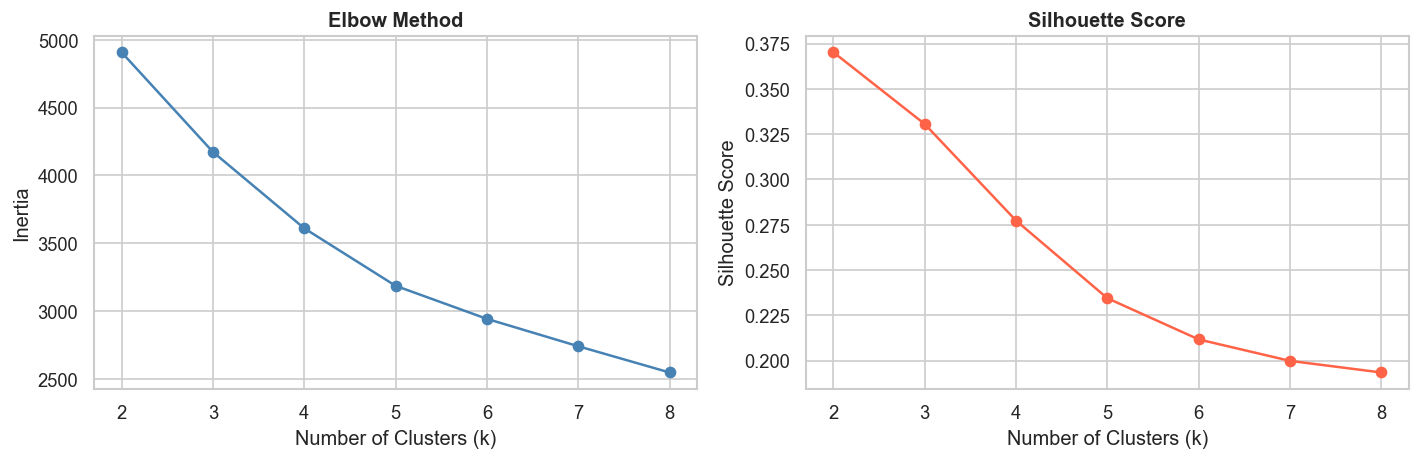

k=2: silhouette=0.370
k=3: silhouette=0.331
k=4: silhouette=0.277
k=5: silhouette=0.234
k=6: silhouette=0.212
k=7: silhouette=0.200
k=8: silhouette=0.193


In [4]:
# FIND OPTIMAL K WITH ELBOW + SILHOUETTE
features_for_clustering = ['avg_review', 'late_rate', 'avg_processing', 
                            'avg_freight_ratio', 'avg_price']

X = seller_features[features_for_clustering].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertias = []
silhouettes = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(k_range, inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(k_range, silhouettes, marker='o', color='tomato')
axes[1].set_title('Silhouette Score', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('../visuals/09_optimal_k.png', dpi=120)
plt.show()

for k, s in zip(k_range, silhouettes):
    print(f"k={k}: silhouette={s:.3f}")

In [5]:
# FIT FINAL MODEL WITH k=3
import os
os.environ['OMP_NUM_THREADS'] = '5'

km_final = KMeans(n_clusters=3, random_state=42, n_init=10)
seller_features['cluster'] = km_final.fit_predict(X_scaled)

# Profile each cluster
cluster_profile = seller_features.groupby('cluster').agg(
    n_sellers=('total_orders', 'count'),
    avg_orders=('total_orders', 'mean'),
    avg_review=('avg_review', 'mean'),
    late_rate=('late_rate', 'mean'),
    avg_processing=('avg_processing', 'mean'),
    avg_price=('avg_price', 'mean'),
    total_revenue=('total_revenue', 'sum')
).round(2)

print(cluster_profile)

         n_sellers  avg_orders  avg_review  late_rate  avg_processing  \
cluster                                                                 
0              306       75.68        3.72       0.13            4.74   
1              876       76.01        4.27       0.04            2.01   
2               54       36.09        4.12       0.07            3.43   

         avg_price  total_revenue  
cluster                            
0           116.70     2646001.83  
1           117.41     7984657.60  
2           801.45     1410870.70  


C:\Users\BURCU\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=5.
  warnings.warn(


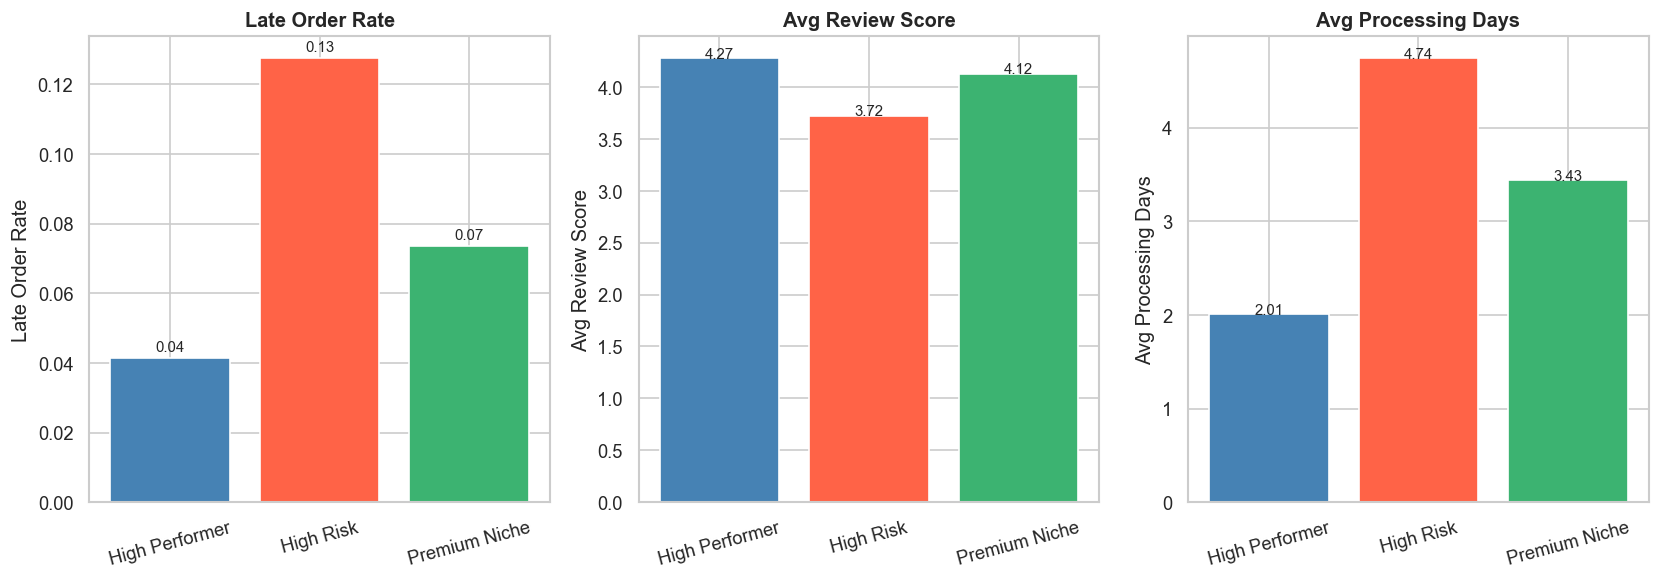

In [6]:
# VISUALIZE CLUSTERS
cluster_labels = {0: 'High Risk', 1: 'High Performer', 2: 'Premium Niche'}
seller_features['cluster_name'] = seller_features['cluster'].map(cluster_labels)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
colors = {'High Risk': 'tomato', 'High Performer': 'steelblue', 'Premium Niche': 'mediumseagreen'}

for ax, (metric, label) in zip(axes, [
    ('late_rate', 'Late Order Rate'),
    ('avg_review', 'Avg Review Score'),
    ('avg_processing', 'Avg Processing Days')
]):
    data = seller_features.groupby('cluster_name')[metric].mean()
    bars = ax.bar(data.index, data.values, 
                  color=[colors[c] for c in data.index], edgecolor='white')
    ax.set_title(label, fontweight='bold')
    ax.set_ylabel(label)
    ax.tick_params(axis='x', rotation=15)
    for bar, val in zip(bars, data.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('../visuals/10_cluster_profiles.png', dpi=120)
plt.show()

In [7]:
# NOTEBOOK 04 SUMMARY
print("""
Notebook 04 — Seller Clustering Complete
=========================================
3 Seller Segments Identified:

  High Performer  (876 sellers): 4% late rate, 2.01 day processing, 
                                  4.27 avg review, 7.98M BRL revenue
  High Risk       (306 sellers): 13% late rate, 4.74 day processing,
                                  3.72 avg review, 2.65M BRL revenue
  Premium Niche   (54 sellers):  7% late rate, 801 BRL avg price,
                                  4.12 avg review, 1.41M BRL revenue

Strategic Implication: High Risk sellers represent 25% of the seller 
base but generate disproportionate customer dissatisfaction. Targeted 
SLA enforcement on this segment could significantly improve platform-
wide satisfaction scores.

Ready for Notebook 05: Strategic Insights & Recommendations
""")


Notebook 04 — Seller Clustering Complete
3 Seller Segments Identified:

  High Performer  (876 sellers): 4% late rate, 2.01 day processing, 
                                  4.27 avg review, 7.98M BRL revenue
  High Risk       (306 sellers): 13% late rate, 4.74 day processing,
                                  3.72 avg review, 2.65M BRL revenue
  Premium Niche   (54 sellers):  7% late rate, 801 BRL avg price,
                                  4.12 avg review, 1.41M BRL revenue

Strategic Implication: High Risk sellers represent 25% of the seller 
base but generate disproportionate customer dissatisfaction. Targeted 
SLA enforcement on this segment could significantly improve platform-
wide satisfaction scores.

Ready for Notebook 05: Strategic Insights & Recommendations

